<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20Force011.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
grid_size = 512
e_folds = 10000
collapse_factor = 1.5  # Density amplification
beta_collapse = 1/256  # Echo–curvature coupling


In [2]:
def generate_dense_echo(grid_size, collapse_factor):
    x = np.linspace(0, 4*np.pi, grid_size)
    y = np.linspace(0, 4*np.pi, grid_size)
    X, Y = np.meshgrid(x, y)
    return collapse_factor * (np.sin(X) + np.sin(Y))


In [3]:
def collapse_coupling(field, beta=1/256):
    grad_x, grad_y = np.gradient(field)
    theta = np.arctan2(grad_y, grad_x)
    curvature = -beta * np.sin(theta)
    field += curvature
    return field


In [4]:
def evolve_field(field, steps, decay=0.9999):
    evolved = field.copy()
    for _ in range(steps):
        evolved *= decay
        evolved += np.random.normal(0, 0.001, field.shape)
    return evolved


In [5]:
def memory_fidelity(original, evolved):
    return np.corrcoef(original.flatten(), evolved.flatten())[0,1]

def core_saturation(field):
    center = field[grid_size//2-10:grid_size//2+10, grid_size//2-10:grid_size//2+10]
    return np.mean(center**2)


Collapse fidelity: 0.9930
Core saturation energy: 0.015672


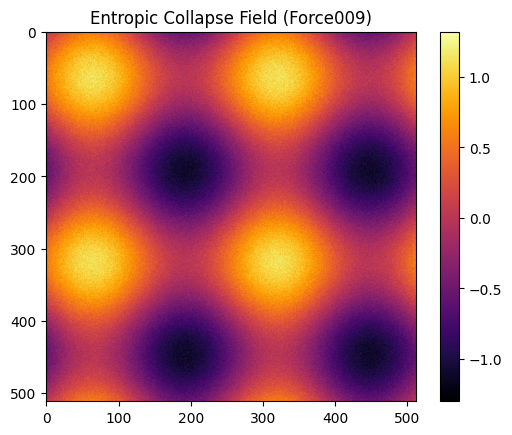

In [6]:
field = generate_dense_echo(grid_size, collapse_factor)
field_c = collapse_coupling(field, beta_collapse)
field_e = evolve_field(field_c, e_folds)

fidelity = memory_fidelity(field_c, field_e)
saturation = core_saturation(field_e)

print(f"Collapse fidelity: {fidelity:.4f}")
print(f"Core saturation energy: {saturation:.6f}")

plt.imshow(field_e, cmap='inferno')
plt.title("Entropic Collapse Field (Force009)")
plt.colorbar()
plt.show()
